In [2]:
path = '/home/user/Desktop/diploma'

In [3]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

In [4]:
sys.path.append(os.path.abspath(path+'/eraserbenchmark-master'))
from rationale_benchmark.utils import annotations_from_jsonl

In [5]:
import json

def model_acc(model, task):
    exp_results = f"analysis_m-{model}_y-none_d-{'imdb' if task == 'movies' else 'rte'}_p-test_t-counterfactual_c-_s-0.json"
    json_path = os.path.join(path, "introspections/results/analysis", exp_results)   
    with open(json_path, 'r') as f:
        data = json.load(f)   
    total = data['results']['total']
    correct = data['results']['correct']
    accuracy = correct / total if total > 0 else 0
    return accuracy

model_acc('llama3-8b', 'movies')

0.9748743718592965

In [6]:
def crest_acc(task):
    if task=="movies":
        crest_res = pd.read_csv(os.path.join(path, f'crest/data/rationales/e_movies_test_sparsemap_50p.tsv'), sep='\t')
    else:
        crest_res = pd.read_csv(os.path.join(path, f'crest/data/rationales/e_snli_test_sparsemap_30p.tsv'), sep='\t')
       

    correct_predictions = (crest_res['labels'] == crest_res['predictions']).sum()   
    total_predictions = len(crest_res)
    accuracy = (correct_predictions / total_predictions)

    return accuracy

In [51]:
for task in ['movies', 'esnli']:
    print()
    print(task)
    print("Crest Accuracy:", crest_acc(task))
    for model in ['llama3-1b','llama3-3b','llama3-8b','llama3-70b','qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b', 'qwen-72b']:
        acc = model_acc(model, task)
        print(f"Model: {model}, Task: {task}, Accuracy: {acc:.4f}")


movies
Crest Accuracy: 0.8442211055276382
Model: llama3-1b, Task: movies, Accuracy: 0.3618
Model: llama3-3b, Task: movies, Accuracy: 0.8141
Model: llama3-8b, Task: movies, Accuracy: 0.9749
Model: llama3-70b, Task: movies, Accuracy: 0.9698
Model: qwen-1b, Task: movies, Accuracy: 0.9045
Model: qwen-3b, Task: movies, Accuracy: 0.8543
Model: qwen-7b, Task: movies, Accuracy: 0.9447
Model: qwen-14b, Task: movies, Accuracy: 0.9397
Model: qwen-32b, Task: movies, Accuracy: 0.9749
Model: qwen-72b, Task: movies, Accuracy: 0.9799

esnli
Crest Accuracy: 0.6383752652318885
Model: llama3-1b, Task: esnli, Accuracy: 0.6363
Model: llama3-3b, Task: esnli, Accuracy: 0.7132
Model: llama3-8b, Task: esnli, Accuracy: 0.8503
Model: llama3-70b, Task: esnli, Accuracy: 0.9633
Model: qwen-1b, Task: esnli, Accuracy: 0.9230
Model: qwen-3b, Task: esnli, Accuracy: 0.7813
Model: qwen-7b, Task: esnli, Accuracy: 0.9333
Model: qwen-14b, Task: esnli, Accuracy: 0.8668
Model: qwen-32b, Task: esnli, Accuracy: 0.9373
Model: q

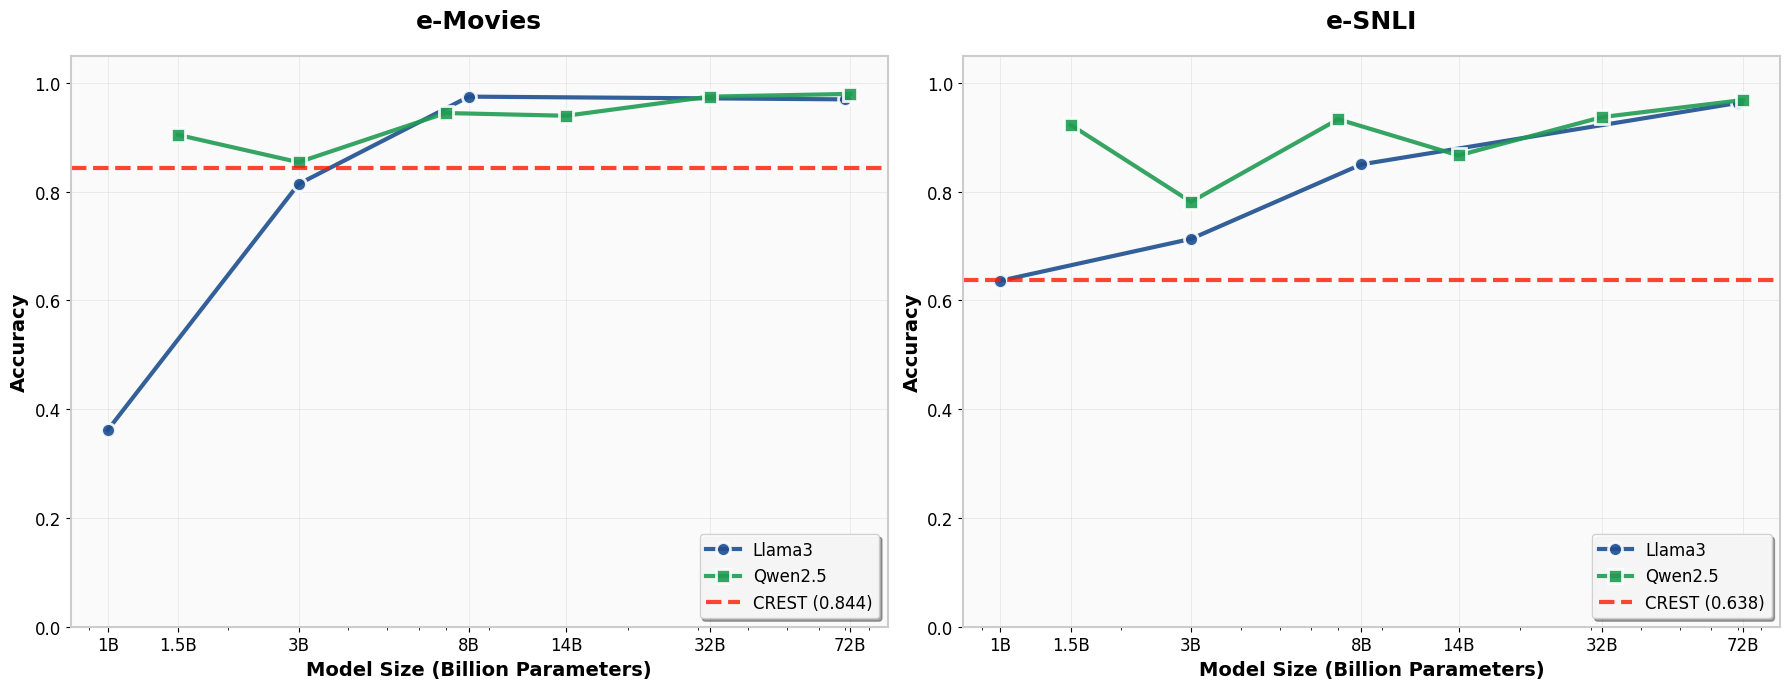

In [17]:
# Create plots for both tasks
import numpy as np

# Collect data for plotting
tasks = ['movies', 'esnli']
models = ['llama3-1b','llama3-3b','llama3-8b','llama3-70b','qwen-1b','qwen-3b','qwen-7b','qwen-14b','qwen-32b', 'qwen-72b']

# Prepare data
data = {}
for task in tasks:
    data[task] = {
        'models': ['CREST'] + models,
        'accuracies': [crest_acc(task)] + [model_acc(model, task) for model in models]
    }

# Separate models by family with their parameter sizes
llama_models = ['llama3-1b', 'llama3-3b', 'llama3-8b', 'llama3-70b']
llama_params = [1, 3, 8, 70]  # Parameter sizes in billions

qwen_models = ['qwen-1b', 'qwen-3b', 'qwen-7b', 'qwen-14b', 'qwen-32b', 'qwen-72b']
qwen_params = [1.5, 3, 7, 14, 32, 72]  # Parameter sizes in billions

# Prepare data for each model family
llama_data = {}
qwen_data = {}

for task in tasks:
    llama_data[task] = {
        'models': llama_models,
        'params': llama_params,
        'accuracies': [model_acc(model, task) for model in llama_models]
    }
    qwen_data[task] = {
        'models': qwen_models,
        'params': qwen_params,
        'accuracies': [model_acc(model, task) for model in qwen_models]
    }

# Create 2 plots (1x2 grid) - one for each task with both model families
plt.style.use('default')
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

tasks = ['movies', 'esnli']
task_titles = ['e-Movies', 'e-SNLI']

# Define better colors and styles
llama_color = "#1E4F90"  # Blue
qwen_color = "#209C54"   # Green
crest_color = "#FF1900"  # Red

for idx, task in enumerate(tasks):
    ax = axes[idx]
    
    # Get CREST accuracy
    crest_accuracy = crest_acc(task)
    
    # Plot Llama3 models with improved styling
    llama_accuracies = llama_data[task]['accuracies']
    llama_params = llama_data[task]['params']
    ax.plot(llama_params, llama_accuracies, 'o-', linewidth=3, markersize=10, 
            color=llama_color, label='Llama3', alpha=0.9, markeredgecolor='white', markeredgewidth=2)
    
    # Plot Qwen models with improved styling
    qwen_accuracies = qwen_data[task]['accuracies']
    qwen_params = qwen_data[task]['params']
    ax.plot(qwen_params, qwen_accuracies, 's-', linewidth=3, markersize=10, 
            color=qwen_color, label='Qwen2.5', alpha=0.9, markeredgecolor='white', markeredgewidth=2)
    
    # Add CREST as horizontal reference line with improved styling
    ax.axhline(y=crest_accuracy, color=crest_color, linestyle='--', linewidth=3, 
               label=f'CREST ({crest_accuracy:.3f})', alpha=0.8)
    
    # Set x-axis to log scale
    ax.set_xscale('log')
    
    # Customize plot with better typography and spacing
    ax.set_title(f'{task_titles[idx]}', fontsize=18, fontweight='bold', pad=20)
    ax.set_xlabel('Model Size (Billion Parameters)', fontsize=14, fontweight='600')
    ax.set_ylabel('Accuracy', fontsize=14, fontweight='600')
    ax.set_ylim(0, 1.05)  # Start y-axis from 0
    
    # Select specific parameter sizes for x-axis ticks to avoid overlap
    selected_params = [1, 1.5, 3, 8, 14, 32, 72]  # Skip 7 and 70 to reduce overlap
    ax.set_xticks(selected_params)
    ax.set_xticklabels([f'{p}B' for p in selected_params], fontsize=12)
    ax.tick_params(axis='y', labelsize=12)
    
    # Enhanced legend with better styling
    legend = ax.legend(loc='lower right', fontsize=12, frameon=True, 
                      fancybox=True, shadow=True, framealpha=0.9)
    legend.get_frame().set_facecolor('white')
    
    # Enhanced grid
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    ax.set_facecolor('#fafafa')  # Light background
    
    # Add subtle border
    for spine in ax.spines.values():
        spine.set_linewidth(1.5)
        spine.set_color('#cccccc')

plt.tight_layout()
plt.savefig(os.path.join(path, 'results/classifier_accuracy_comparison.png'), dpi=300, bbox_inches='tight')
plt.show()